In [1]:
# Plotting global pm2.5 mortality using central estimates

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from utils.utils import autosize_figure, get_scenario_config

In [3]:
def load_mortality_ensemble_members(model, scenario, config):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/pm25/gridpoint_mortality/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Mortality_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataarray(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [6]:
# === Scenario and path config ===
# Set to whatever scenario and model you want
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/pm25/Gridpoint/"

model = "CESM2"
scenario1 = "SSP245_G6"
scenario2 = "G6-1.5K"

config1 = get_scenario_config(model, scenario1)
config2 = get_scenario_config(model, scenario2)

ensemble_members = config1["ensemble_members"]

da1 = load_mortality_ensemble_members(model, scenario1, config1)
da2 = load_mortality_ensemble_members(model, scenario2, config2)

da1_global = da1.sum(dim=("lat", "lon"))
da2_global = da2.sum(dim=("lat", "lon"))

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


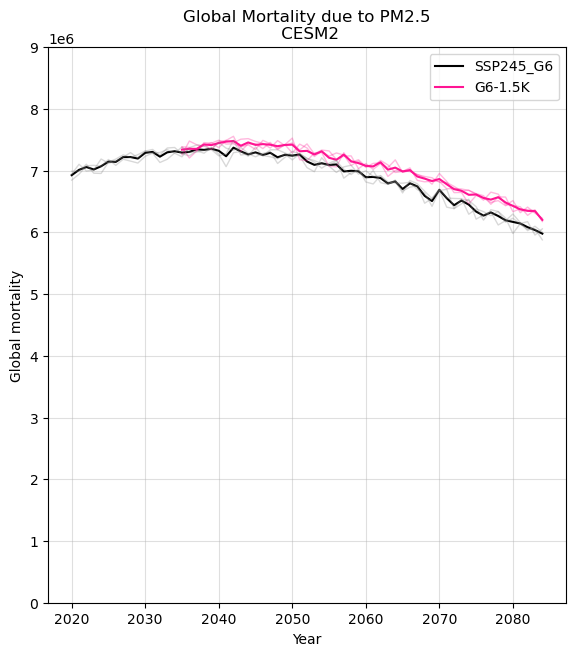

In [27]:
plt.figure(figsize=autosize_figure(1, 1, xscale_factor=0.8, yscale_factor=1.2))

da1_global.mean("ensemble").plot(color="k", label=scenario1)
da2_global.mean("ensemble").plot(color="deeppink", label=scenario2)
for ens_num in ensemble_members:
    da1_global.sel(ensemble=ens_num).plot(color="grey", alpha=0.3, lw=1)
    da2_global.sel(ensemble=ens_num).plot(color="deeppink", alpha=0.3, lw=1)

plt.ylim(0, 9e6)
plt.grid(True, alpha=0.4)
plt.xlabel("Year")
plt.ylabel("Global mortality")
plt.legend()
plt.title(f"Global Mortality due to PM2.5\n {model}")
plt.show()

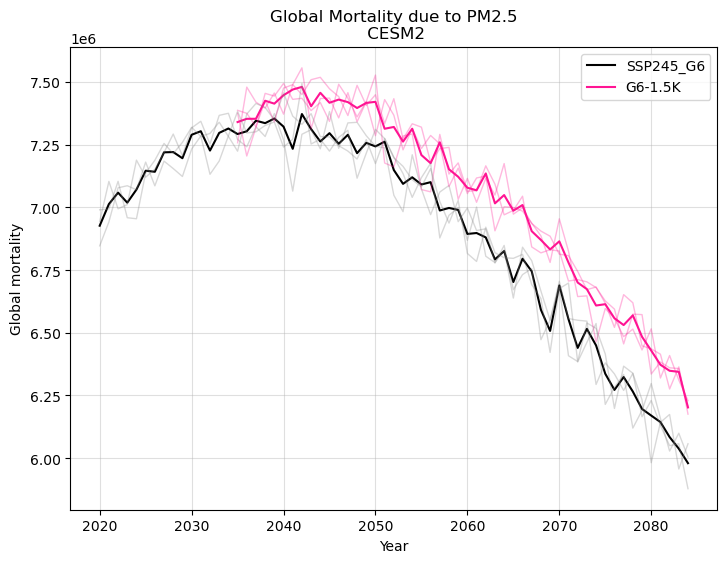

In [28]:
plt.figure(figsize=autosize_figure(1, 1))

da1_global.mean("ensemble").plot(color="k", label=scenario1)
da2_global.mean("ensemble").plot(color="deeppink", label=scenario2)
for ens_num in ensemble_members:
    da1_global.sel(ensemble=ens_num).plot(color="grey", alpha=0.3, lw=1)
    da2_global.sel(ensemble=ens_num).plot(color="deeppink", alpha=0.3, lw=1)

#plt.ylim(0, 9e6)
plt.grid(True, alpha=0.4)
plt.xlabel("Year")
plt.ylabel("Global mortality")
plt.legend()
plt.title(f"Global Mortality due to PM2.5\n {model}")
plt.show()

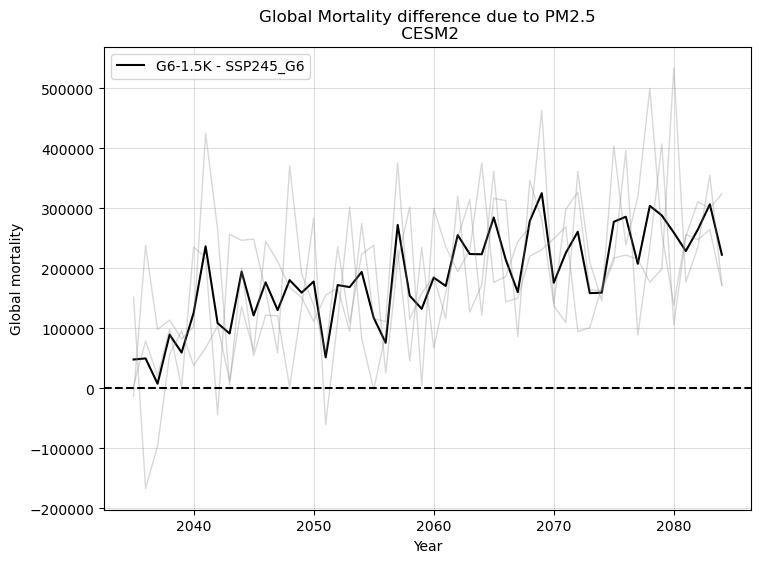

In [32]:
difference = da2_global - da1_global  # SAI - noSAI

plt.figure(figsize=autosize_figure(1, 1))

difference.mean("ensemble").plot(color="k", label=f"{scenario2} - {scenario1}")
for ens_num in ensemble_members:
    difference.sel(ensemble=ens_num).plot(color="grey", alpha=0.3, lw=1)
plt.axhline(0, color="k", ls="--", lw=1.5)

#plt.ylim(0, 9e6)
plt.grid(True, alpha=0.4)
plt.xlabel("Year")
plt.ylabel("Global mortality")
plt.legend()
plt.title(f"Global Mortality difference due to PM2.5\n {model}")
plt.show()